In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
import os
import pandas as pd

In [3]:
# Download absorption coefficients of Water

PATH_WATER = "Data_eau.csv"

water_df = pd.read_csv(PATH_WATER, header=None, names=["wavelength", "Water_abs"])
water_df["Water_abs_mm-1"] = (water_df["Water_abs"].values)/10

# target wavelength grid
wl_grid = np.arange(600, 1001, 2)   # 600, 602, 604, ..., 1000

# interpolate
water_interp = np.interp(wl_grid, water_df["wavelength"].values, water_df["Water_abs_mm-1"].values)

water_interp_df = pd.DataFrame({
    "wavelength": wl_grid,
    "Water_abs_mm-1": water_interp
})

wavelength_water = water_interp_df["wavelength"].values
mu_a_water = water_interp_df["Water_abs_mm-1"].values

print(water_interp_df)

     wavelength  Water_abs_mm-1
0           600        0.000190
1           602        0.000201
2           604        0.000212
3           606        0.000223
4           608        0.000234
..          ...             ...
196         992        0.035021
197         994        0.035351
198         996        0.035680
199         998        0.036010
200        1000        0.036339

[201 rows x 2 columns]


In [4]:
# Download extinction coefficients for HbO2 and Hb

df = pd.read_csv("hemoglobin_extinction_partial.csv")

x = 150  # g/L
df["mu_a_HbO2_mm-1"] = (2.303 * df["HbO2_cm-1_M"] * x / 64500)/10
df["mu_a_Hb_mm-1"]   = (2.303 * df["Hb_cm-1_M"]  * x / 64500)/10
df = df[df["lambda_nm"].between(600, 1000)]

wavelength = df["lambda_nm"].values
mu_a_HbO2 = df["mu_a_HbO2_mm-1"].values
mu_a_Hb = df["mu_a_Hb_mm-1"].values

print(df)

     lambda_nm  HbO2_cm-1_M  Hb_cm-1_M  mu_a_HbO2_mm-1  mu_a_Hb_mm-1
175      600.0       3200.0  14677.200        1.713860      7.860835
176      602.0       2664.0  13622.400        1.426789      7.295904
177      604.0       2128.0  12567.600        1.139717      6.730973
178      606.0       1789.2  11513.200        0.958262      6.166256
179      608.0       1647.6  10477.600        0.882424      5.611608
..         ...          ...        ...             ...           ...
371      992.0       1068.8    267.932        0.572429      0.143499
372      994.0       1057.6    252.648        0.566431      0.135314
373      996.0       1046.4    237.360        0.560432      0.127126
374      998.0       1035.2    222.072        0.554434      0.118938
375     1000.0       1024.0    206.784        0.548435      0.110750

[201 rows x 5 columns]


In [5]:
# Create original mesh

# --- 1. Define mesh grid ---
x_max = 10
x_step = 0.1
x = np.arange(0, x_max + x_step, x_step)

layer_thickness = [0.02, 0.25, 0.10, 0.08, 0.20, 0.30]
z_max = sum(layer_thickness)
z_step = 0.001
z = np.arange(0, z_max, z_step)

X, Z = np.meshgrid(x, z)

# --- 2. Initialize property arrays ---
n = np.zeros_like(X)
mu_s = np.zeros_like(X)

# 3D absorption array
mu_a = np.zeros((len(wavelength), *X.shape))

# --- 3. Assign refractive index and scattering ---
layer_edges = np.cumsum(layer_thickness)

mask = Z < layer_edges[1]
n[mask] = 1.42
mu_s[mask] = 20.1

mask = Z >= layer_edges[1]
n[mask] = 1.39
mu_s[mask] = 20.1


# --- Layer masks ---
stratum = Z < layer_edges[0]
epiderme = (Z >= layer_edges[0]) & (Z < layer_edges[1])
papille_dermique = (Z >= layer_edges[1]) & (Z < layer_edges[2])
derme_supérieur = (Z >= layer_edges[2]) & (Z < layer_edges[3])
derme_réticulaire = (Z >= layer_edges[3]) & (Z < layer_edges[4])
derme_profond = (Z >= layer_edges[4]) & (Z <= layer_edges[5])


# --- Precompute wavelength dependent spectra ---
mu_a_mel = 6.6e10 * (wavelength ** -3.33)
mu_a_baseline = 7.84e7 * (wavelength ** -3.255)

V_mel = 0.1


for i, wn in enumerate(wavelength):

    mu_mel = mu_a_mel[i]
    mu_baseline = mu_a_baseline[i]
    mu_water = mu_a_water[i]

    # --- Stratum corneum ---
    V_water_stratum = 0.05
    mu_stratum = (
        V_mel * mu_mel +
        V_water_stratum * mu_water +
        (1 - (V_mel + V_water_stratum)) * mu_baseline
    )

    mu_a[i][stratum] = mu_stratum


    # --- Epidermis ---
    V_water_epiderme = 0.2
    mu_epiderme = (
        V_mel * mu_mel +
        V_water_epiderme * mu_water +
        (1 - (V_mel + V_water_epiderme)) * mu_baseline
    )

    mu_a[i][epiderme] = mu_epiderme


    # --- Hemoglobin absorption ---
    mu_Hb = mu_a_Hb[i]
    mu_HbO2 = mu_a_HbO2[i]

    SaO2 = 0.98
    SvO2 = SaO2 - 0.1

    mu_A = SaO2 * mu_HbO2 + (1 - SaO2) * mu_Hb
    mu_V = SvO2 * mu_HbO2 + (1 - SvO2) * mu_Hb


    # --- Papillary dermis ---
    Vb = 0.04
    Vw = 0.5

    mu_val = (
        0.5 * Vb * (mu_A + mu_V)
        + Vw * mu_water
        + (1 - (Vb + Vw)) * mu_baseline
    )

    mu_a[i][papille_dermique] = mu_val


    # --- Upper dermis ---
    Vb = 0.3
    Vw = 0.6

    mu_val = (
        0.5 * Vb * (mu_A + mu_V)
        + Vw * mu_water
        + (1 - (Vb + Vw)) * mu_baseline
    )

    mu_a[i][derme_supérieur] = mu_val


    # --- Reticular dermis ---
    Vb = 0.04
    Vw = 0.7

    mu_val = (
        0.5 * Vb * (mu_A + mu_V)
        + Vw * mu_water
        + (1 - (Vb + Vw)) * mu_baseline
    )

    mu_a[i][derme_réticulaire] = mu_val


    # --- Deep dermis ---
    Vb = 0.1
    Vw = 0.7

    mu_val = (
        0.5 * Vb * (mu_A + mu_V)
        + Vw * mu_water
        + (1 - (Vb + Vw)) * mu_baseline
    )

    mu_a[i][derme_profond] = mu_val

print(mu_a.shape)

(201, 950, 101)


In [6]:
import numpy as np

def simulate_light_propagation(mu_abs, mu_s, n):
    g = 0.9
    Wc = 0.01
    m = 10
    Nz, Nx = mu_abs.shape
    N_photons = 5000

    rng = np.random.default_rng()

    # initialize absorption map
    A = np.zeros_like(mu_abs)

    # compute max coordinates
    x_max = Nx * x_step
    z_max = Nz * z_step

    for p in range(N_photons):
        W = 1.0
        mu_x = 0
        mu_z = 1
        x = x_max / 2
        z = 0

        while True:
            # convert to voxel indices
            ix = int(x / x_step)
            iz = int(z / z_step)

            # stop photon if outside medium
            if ix < 0 or ix >= Nx or iz < 0 or iz >= Nz:
                break

            # total interaction coefficient at current voxel
            mu_t = mu_s[iz, ix] + mu_abs[iz, ix]
            if mu_t <= 0:
                print("Shit")
                break  # stop photon if no scattering/absorption

            # mean free path
            s = -np.log(rng.uniform()) / mu_t

            # --- Fresnel reflection/transmission ---
            next_z = z + mu_z * s
            next_iz = int(next_z / z_step)
            if 0 <= next_iz < Nz:
                n1 = n[iz, ix]
                n2 = n[next_iz, ix]
                if n1 != n2:  # interface detected
                    theta_i = np.arccos(abs(mu_z))  # angle with normal
                    sin_theta_t = n1 / n2 * np.sin(theta_i)
                    if sin_theta_t > 1:  # total internal reflection
                        mu_z = -mu_z
                    else:
                        theta_t = np.arcsin(sin_theta_t)
                        cos_theta_i = np.cos(theta_i)
                        cos_theta_t = np.cos(theta_t)
                        Rs = ((n1 * cos_theta_i - n2 * cos_theta_t) / 
                              (n1 * cos_theta_i + n2 * cos_theta_t))**2
                        Rp = ((n1 * cos_theta_t - n2 * cos_theta_i) / 
                              (n1 * cos_theta_t + n2 * cos_theta_i))**2
                        R = 0.5 * (Rs + Rp)
                        if rng.uniform() < R:
                            mu_z = -mu_z  # reflect
                        else:
                            mu_z = np.sign(mu_z) * cos_theta_t  # transmit
                            # adjust horizontal component to conserve direction magnitude
                            if np.sin(theta_i) < 1e-12:  # photon moving almost perfectly vertical
                                # horizontal component stays the same
                                mu_x = mu_x
                            else:
                                mu_x = mu_x * np.sin(theta_t) / np.sin(theta_i)

            # propagate photon
            x += mu_x * s
            z += mu_z * s

            # convert new positions to voxel indices
            ix = int(x / x_step)
            iz = int(z / z_step)

            # stop if outside
            if ix < 0 or ix >= Nx or iz < 0 or iz >= Nz:
                break

            # recalc total interaction coefficient at new voxel
            mu_t = mu_s[iz, ix] + mu_abs[iz, ix]

            # absorption
            deltaW = (mu_abs[iz, ix]/mu_t) * W
            W -= deltaW
            A[iz, ix] += deltaW

            # Russian roulette
            if W < Wc:
                if rng.uniform() <= 1/m:
                    W *= m
                else:
                    break

            # Diffusion (2D Henyey-Greenstein)
            e2 = rng.uniform()
            e3 = rng.uniform()
            phi = 2 * np.pi * e2
            cos_theta = (1/(2*g))*(1 + g**2 - ((1-g**2)/(1-g + 2*g*e3))**2)
            sin_theta = np.sqrt(1 - cos_theta**2)
            mu_x_new = sin_theta * np.cos(phi)
            mu_z_new = np.sign(mu_z) * cos_theta
            mu_x, mu_z = mu_x_new, mu_z_new

    A /= N_photons
    return A

In [7]:
import numpy as np
import matplotlib.pyplot as plt

X_PERCENT = 0.9  # 90% of absorbed energy
max_depths = []

for i, wl in enumerate(wavelength):
    print(wl)
    mu_a_current = mu_a[i]  # absorption map (Nz, Nx)
    print(mu_a_current.max())
    A = simulate_light_propagation(mu_a_current, mu_s, n)  # returns (Nz, Nx)

    # sum absorption along x to get total absorbed energy per z
    absorption_per_z = A.sum(axis=1)  # shape (Nz,)

    # cumulative absorption from surface to depth
    cumulative = np.cumsum(absorption_per_z)

    # normalize to fraction of total absorbed energy
    cumulative_frac = cumulative / cumulative[-1]

    # find the first depth where cumulative fraction >= X_PERCENT
    iz_90 = np.searchsorted(cumulative_frac, X_PERCENT)

    depth_90 = iz_90 * z_step  # convert index to physical depth
    max_depths.append(depth_90)

# plot
plt.figure(figsize=(6,4))
plt.plot(wavelength, max_depths, '-o')
plt.xlabel("Wavelength (nm)")
plt.ylabel(f"Depth at {int(X_PERCENT*100)}% cumulative absorption (mm)")
plt.title("Effective penetration depth per wavelength")
plt.grid(True)
plt.show()

600.0
3.761223544349355
602.0
3.71978904027385
604.0
3.678946172148853
606.0
3.6386845748812626
608.0
3.5989940983381343
610.0
3.5598648022011217
612.0
3.521286689007962


KeyboardInterrupt: 

# EXPLORATION

wavelength = 660 nm
angle = 80 deg
N_photons = 100000
refine_factor = 10
interaction_scale = 0.05
reflection_override = 0.2
approx mu_t(scaled, top-center) = 1.141935 mm^-1
approx mean free path = 0.875707 mm


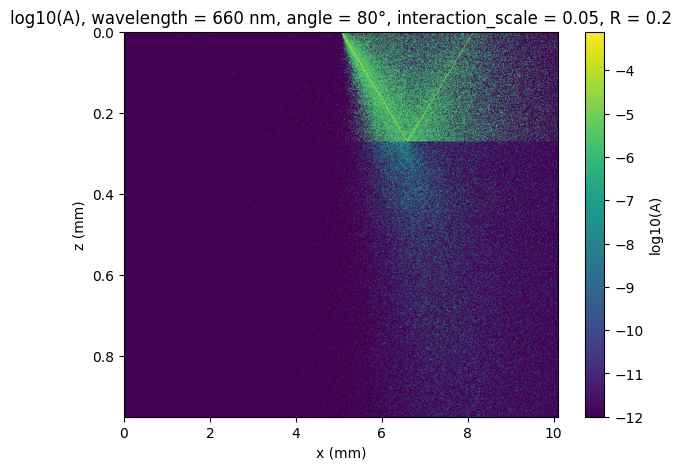

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Helps refine x-grid to reduce staircase artifacts
# =========================================================
def refine_x_grid(field_2d, refine_factor=10):
    return np.repeat(field_2d, refine_factor, axis=1)


# =========================================================
# Main simulation with CORRECT interface crossing:
# - propagate to interface
# - reflect/transmit
# - propagate remaining step
# =========================================================
def simulate_light_propagation(
    mu_abs,
    mu_s,
    n,
    x_step_local,
    z_step_local,
    theta0_deg=0.0,
    N_photons=5000,
    interaction_scale=1.0,
    reflection_override="N",
    debug=False,
    max_debug_prints=30,
):
    g = 0.9
    Wc = 0.01
    m = 10

    Nz, Nx = mu_abs.shape
    rng = np.random.default_rng()

    mu_abs_eff = interaction_scale * mu_abs
    mu_s_eff = interaction_scale * mu_s

    A = np.zeros_like(mu_abs_eff, dtype=float)

    x_max_local = Nx * x_step_local
    theta0 = np.deg2rad(theta0_deg)

    # Find horizontal interface depths from refractive index profile
    n_profile = n[:, 0]
    interface_rows = np.where(np.diff(n_profile) != 0)[0] + 1
    interface_zs = interface_rows * z_step_local

    debug_count = 0

    for p in range(N_photons):
        W = 1.0

        mu_x = np.sin(theta0)
        mu_z = np.cos(theta0)

        x = x_max_local / 2.0
        z = 0.0

        while True:
            ix = int(x / x_step_local)
            iz = int(z / z_step_local)

            if ix < 0 or ix >= Nx or iz < 0 or iz >= Nz:
                break

            mu_t = mu_s_eff[iz, ix] + mu_abs_eff[iz, ix]
            if mu_t <= 0:
                break

            s = -np.log(rng.uniform()) / mu_t
            R = np.nan

            x_old = x
            z_old = z
            next_z = z + mu_z * s

            crossed_interface = False

            if mu_z > 0:
                candidates = interface_zs[(interface_zs > z_old) & (interface_zs <= next_z)]
                if len(candidates) > 0:
                    z_int = candidates[0]
                    crossed_interface = True
            elif mu_z < 0:
                candidates = interface_zs[(interface_zs < z_old) & (interface_zs >= next_z)]
                if len(candidates) > 0:
                    z_int = candidates[-1]
                    crossed_interface = True

            if crossed_interface:
                # propagate to interface first
                s_to_int = (z_int - z) / mu_z
                s_rem = s - s_to_int

                x = x + mu_x * s_to_int
                z = z_int

                ix_int = int(x / x_step_local)
                if ix_int < 0 or ix_int >= Nx:
                    break

                # identify refractive indices across interface
                if mu_z > 0:
                    iz_above = max(int((z_int - 1e-12) / z_step_local), 0)
                    iz_below = min(int((z_int + 1e-12) / z_step_local), Nz - 1)
                    n1 = n[iz_above, ix_int]
                    n2 = n[iz_below, ix_int]
                else:
                    iz_below = min(int((z_int + 1e-12) / z_step_local), Nz - 1)
                    iz_above = max(int((z_int - 1e-12) / z_step_local), 0)
                    n1 = n[iz_below, ix_int]
                    n2 = n[iz_above, ix_int]

                theta_i = np.arccos(np.clip(abs(mu_z), 0.0, 1.0))
                sin_theta_t = (n1 / n2) * np.sin(theta_i)

                if sin_theta_t > 1.0:
                    # total internal reflection
                    mu_z = -mu_z
                    R = 1.0
                else:
                    theta_t = np.arcsin(sin_theta_t)

                    if reflection_override == "N":
                        cos_theta_i = np.cos(theta_i)
                        cos_theta_t = np.cos(theta_t)

                        Rs = ((n1 * cos_theta_i - n2 * cos_theta_t) /
                              (n1 * cos_theta_i + n2 * cos_theta_t))**2
                        Rp = ((n1 * cos_theta_t - n2 * cos_theta_i) /
                              (n1 * cos_theta_t + n2 * cos_theta_i))**2
                        R = 0.5 * (Rs + Rp)
                    else:
                        R = float(reflection_override)
                        R = np.clip(R, 0.0, 1.0)

                    if rng.uniform() < R:
                        # reflection
                        mu_z = -mu_z
                    else:
                        # transmission
                        mu_z = np.sign(mu_z) * np.cos(theta_t)

                        if np.sin(theta_i) >= 1e-12:
                            mu_x = mu_x * np.sin(theta_t) / np.sin(theta_i)

                        norm = np.sqrt(mu_x**2 + mu_z**2)
                        if norm > 0:
                            mu_x /= norm
                            mu_z /= norm

                # propagate remaining segment after bounce/transmission
                x = x + mu_x * s_rem
                z = z + mu_z * s_rem

            else:
                # no interface crossed: simple propagation
                x = x + mu_x * s
                z = z + mu_z * s

            ix = int(x / x_step_local)
            iz = int(z / z_step_local)

            if ix < 0 or ix >= Nx or iz < 0 or iz >= Nz:
                break

            mu_t = mu_s_eff[iz, ix] + mu_abs_eff[iz, ix]
            if mu_t <= 0:
                break

            deltaW = (mu_abs_eff[iz, ix] / mu_t) * W
            W -= deltaW
            A[iz, ix] += deltaW

            if debug and debug_count < max_debug_prints:
                print(
                    f"photon={p}, ix={ix}, iz={iz}, "
                    f"mu_x={mu_x:.6f}, mu_z={mu_z:.6f}, "
                    f"mu_t={mu_t:.6f}, R={R}, crossed_interface={crossed_interface}"
                )
                debug_count += 1

            if W < Wc:
                if rng.uniform() <= 1 / m:
                    W *= m
                else:
                    break

            # scattering
            e3 = rng.uniform()
            cos_delta = (1 / (2 * g)) * (
                1 + g**2 - ((1 - g**2) / (1 - g + 2 * g * e3))**2
            )
            cos_delta = np.clip(cos_delta, -1.0, 1.0)

            delta = np.arccos(cos_delta)
            if rng.uniform() < 0.5:
                delta = -delta

            mu_x_new = mu_x * np.cos(delta) + mu_z * np.sin(delta)
            mu_z_new = -mu_x * np.sin(delta) + mu_z * np.cos(delta)

            norm = np.sqrt(mu_x_new**2 + mu_z_new**2)
            if norm > 0:
                mu_x = mu_x_new / norm
                mu_z = mu_z_new / norm
            else:
                break

    A /= N_photons
    return A


# =========================================================
# The code to run everything ! 
# =========================================================
def run_angle_simulation(
    wl_test=660,
    theta_test=80,
    N_test=2000,
    refine_factor=10,
    interaction_scale=1.0,
    reflection_override="N",
    debug=False,
    max_debug_prints=30,
):
    if wl_test not in [660, 940]:
        raise ValueError("wl_test must be 660 or 940")

    i_test = np.where(wavelength == wl_test)[0][0]

    mu_a_refined = refine_x_grid(mu_a[i_test], refine_factor=refine_factor)
    mu_s_refined = refine_x_grid(mu_s, refine_factor=refine_factor)
    n_refined = refine_x_grid(n, refine_factor=refine_factor)

    x_step_refined = x_step / refine_factor
    z_step_local = z_step

    mu_t_center_original = mu_a[i_test][0, mu_a[i_test].shape[1] // 2] + mu_s[0, mu_s.shape[1] // 2]
    mu_t_center_scaled = interaction_scale * mu_t_center_original

    print(f"wavelength = {wl_test} nm")
    print(f"angle = {theta_test} deg")
    print(f"N_photons = {N_test}")
    print(f"refine_factor = {refine_factor}")
    print(f"interaction_scale = {interaction_scale}")
    print(f"reflection_override = {reflection_override}")
    print(f"approx mu_t(scaled, top-center) = {mu_t_center_scaled:.6f} mm^-1")
    if mu_t_center_scaled > 0:
        print(f"approx mean free path = {1.0 / mu_t_center_scaled:.6f} mm")

    A_test = simulate_light_propagation(
        mu_abs=mu_a_refined,
        mu_s=mu_s_refined,
        n=n_refined,
        x_step_local=x_step_refined,
        z_step_local=z_step_local,
        theta0_deg=theta_test,
        N_photons=N_test,
        interaction_scale=interaction_scale,
        reflection_override=reflection_override,
        debug=debug,
        max_debug_prints=max_debug_prints,
    )

    x_max_plot = mu_a_refined.shape[1] * x_step_refined
    z_max_plot = mu_a_refined.shape[0] * z_step_local

    plt.figure(figsize=(7, 5))
    plt.imshow(
        np.log10(A_test + 1e-12),
        extent=[0, x_max_plot, z_max_plot, 0],
        aspect='auto',
        cmap='viridis'
    )
    plt.xlabel("x (mm)")
    plt.ylabel("z (mm)")
    plt.title(
        f"log10(A), wavelength = {wl_test} nm, angle = {theta_test}°, "
        f"interaction_scale = {interaction_scale}, R = {reflection_override}"
    )
    plt.colorbar(label="log10(A)")
    plt.show()

    return A_test, x_step_refined, z_step_local




# Angle incident 0°, aucune modulation reflection

wavelength = 660 nm
angle = 0 deg
N_photons = 100000
refine_factor = 10
interaction_scale = 1
reflection_override = N
approx mu_t(scaled, top-center) = 22.838692 mm^-1
approx mean free path = 0.043785 mm


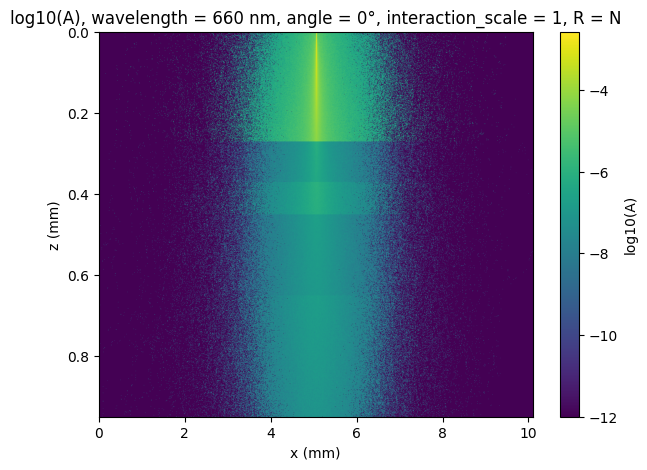

In [13]:
A_half, x_step_refined, z_step_local = run_angle_simulation(
    wl_test=660,
    theta_test=0,
    N_test=100000,
    refine_factor=10,
    interaction_scale=1,
    reflection_override="N",
    debug=False
)

# Angle incident 30°, aucune modulation reflection, $\lambda = 660nm$

wavelength = 660 nm
angle = 30 deg
N_photons = 100000
refine_factor = 10
interaction_scale = 1
reflection_override = N
approx mu_t(scaled, top-center) = 22.838692 mm^-1
approx mean free path = 0.043785 mm


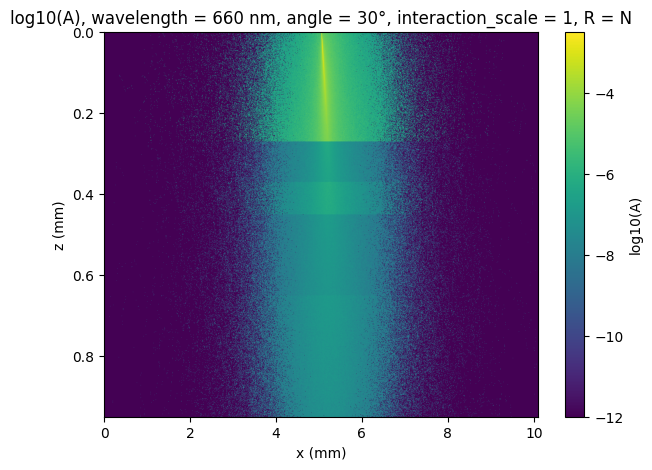

In [15]:
A_half, x_step_refined, z_step_local = run_angle_simulation(
    wl_test=660,
    theta_test=30,
    N_test=100000,
    refine_factor=10,
    interaction_scale=1,
    reflection_override= "N",
    debug=False
)

# Angle incident 30°, aucune modulation reflection, $\lambda = 940nm$

wavelength = 940 nm
angle = 30 deg
N_photons = 100000
refine_factor = 10
interaction_scale = 1
reflection_override = N
approx mu_t(scaled, top-center) = 20.944648 mm^-1
approx mean free path = 0.047745 mm


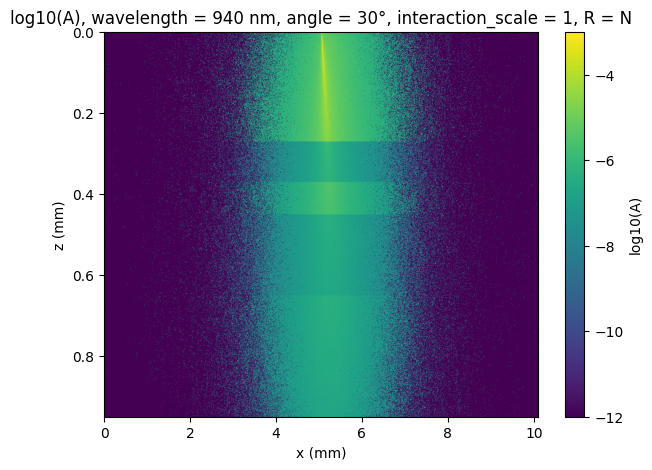

In [17]:
A_half, x_step_refined, z_step_local = run_angle_simulation(
    wl_test=940,
    theta_test=30,
    N_test=100000,
    refine_factor=10,
    interaction_scale=1,
    reflection_override="N",
    debug=False
)

# Angle incident 80°, aucune modulation reflection, $\lambda = 660nm$

wavelength = 660 nm
angle = 80 deg
N_photons = 100000
refine_factor = 10
interaction_scale = 1
reflection_override = N
approx mu_t(scaled, top-center) = 22.838692 mm^-1
approx mean free path = 0.043785 mm


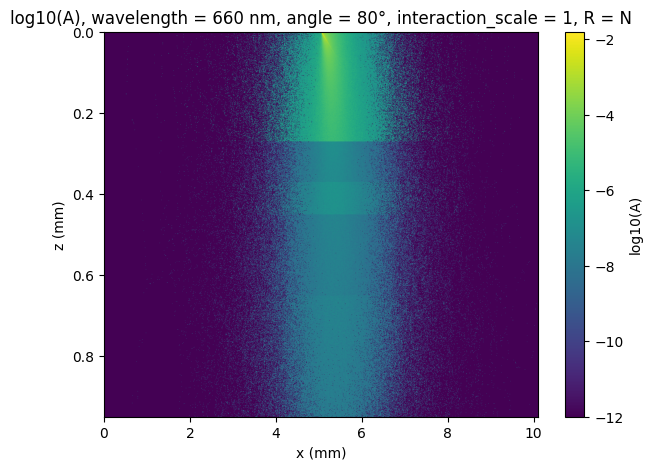

In [18]:
A_half, x_step_refined, z_step_local = run_angle_simulation(
    wl_test=660,
    theta_test=80,
    N_test=100000,
    refine_factor=10,
    interaction_scale=1,
    reflection_override="N",
    debug=False
)

# Angle incident 80°, aucune modulation reflection, $\lambda = 940nm$

wavelength = 940 nm
angle = 80 deg
N_photons = 100000
refine_factor = 10
interaction_scale = 1
reflection_override = N
approx mu_t(scaled, top-center) = 20.944648 mm^-1
approx mean free path = 0.047745 mm


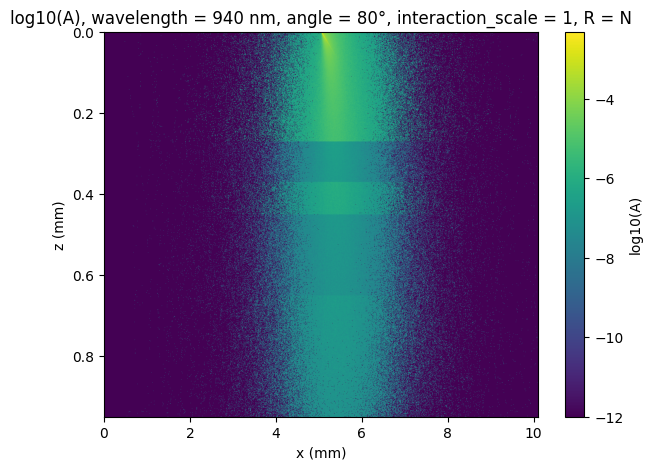

In [19]:
A_half, x_step_refined, z_step_local = run_angle_simulation(
    wl_test=940,
    theta_test=80,
    N_test=100000,
    refine_factor=10,
    interaction_scale=1,
    reflection_override="N",
    debug=False
)

# Angle incident 30°, AVEC modulation reflection et coefficient d'absorption, $\lambda = 660nm$

wavelength = 660 nm
angle = 30 deg
N_photons = 100000
refine_factor = 10
interaction_scale = 0.05
reflection_override = 0.5
approx mu_t(scaled, top-center) = 1.141935 mm^-1
approx mean free path = 0.875707 mm


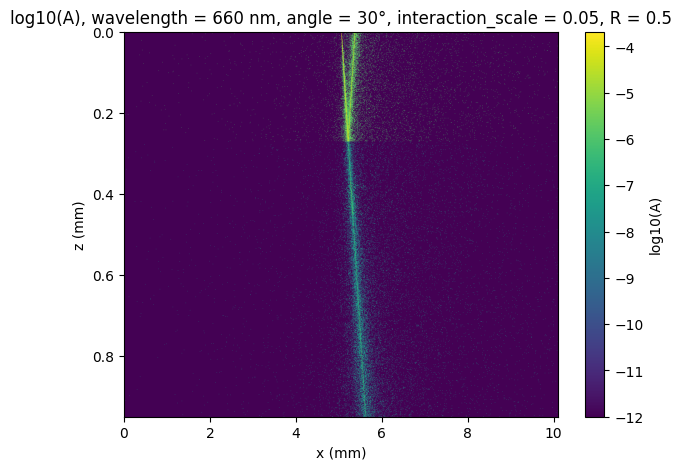

In [20]:
A_half, x_step_refined, z_step_local = run_angle_simulation(
    wl_test=660,
    theta_test=30,
    N_test=100000,
    refine_factor=10,
    interaction_scale=0.05,
    reflection_override=0.5,
    debug=False
)

# Angle incident 30°, AVEC modulation reflection et coefficient d'absorption, $\lambda = 940nm$

wavelength = 940 nm
angle = 30 deg
N_photons = 100000
refine_factor = 10
interaction_scale = 0.05
reflection_override = 0.5
approx mu_t(scaled, top-center) = 1.047232 mm^-1
approx mean free path = 0.954898 mm


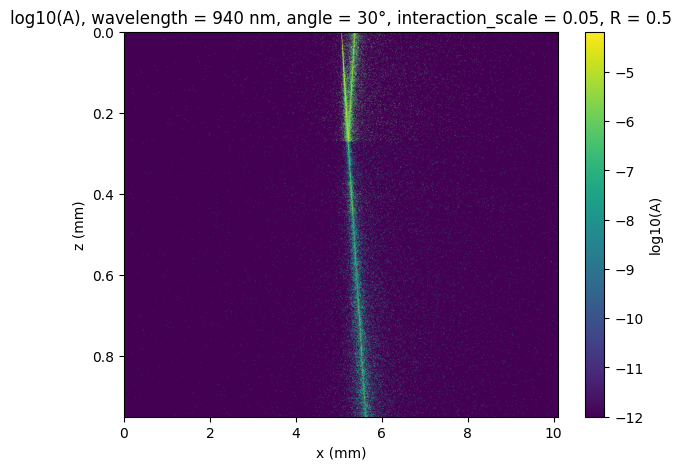

In [21]:
A_half, x_step_refined, z_step_local = run_angle_simulation(
    wl_test=940,
    theta_test=30,
    N_test=100000,
    refine_factor=10,
    interaction_scale=0.05,
    reflection_override=0.5,
    debug=False
)

# Angle incident 80°, AVEC modulation reflection et coefficient d'absorption, $\lambda = 660nm$

wavelength = 660 nm
angle = 80 deg
N_photons = 100000
refine_factor = 10
interaction_scale = 0.05
reflection_override = 0.5
approx mu_t(scaled, top-center) = 1.141935 mm^-1
approx mean free path = 0.875707 mm


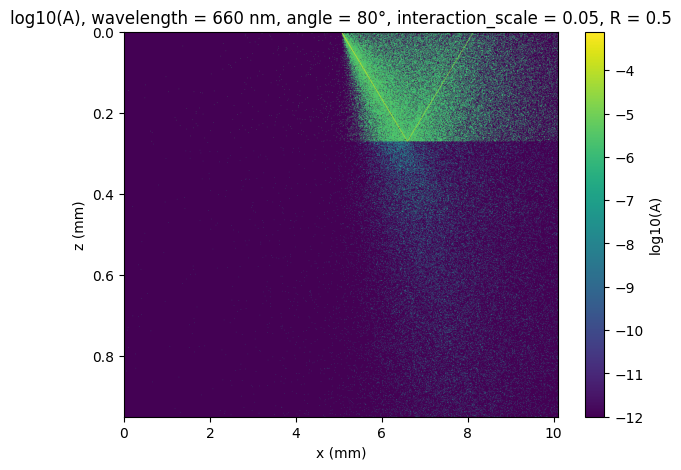

In [22]:
A_half, x_step_refined, z_step_local = run_angle_simulation(
    wl_test=660,
    theta_test=80,
    N_test=100000,
    refine_factor=10,
    interaction_scale=0.05,
    reflection_override=0.5,
    debug=False
)

# Angle incident 80°, AVEC modulation reflection et coefficient d'absorption, $\lambda = 940nm$

wavelength = 940 nm
angle = 80 deg
N_photons = 100000
refine_factor = 10
interaction_scale = 0.05
reflection_override = 0.5
approx mu_t(scaled, top-center) = 1.047232 mm^-1
approx mean free path = 0.954898 mm


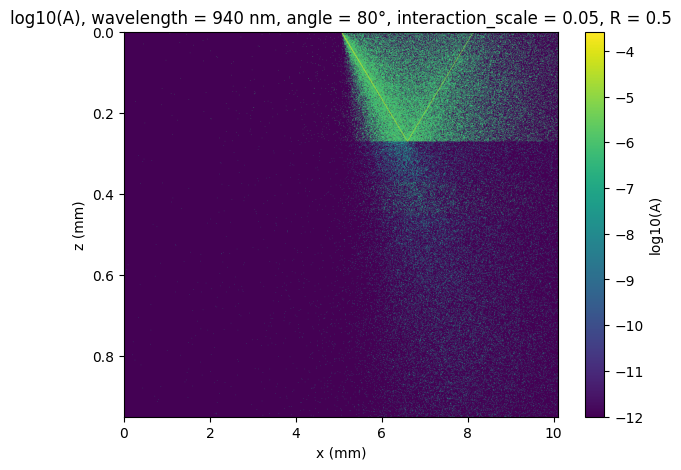

In [23]:
A_half, x_step_refined, z_step_local = run_angle_simulation(
    wl_test=940,
    theta_test=80,
    N_test=100000,
    refine_factor=10,
    interaction_scale=0.05,
    reflection_override=0.5,
    debug=False
)